In [15]:
from tensorflow.keras.models import Sequential

from tensorflow.keras.layers import Input, Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

from tensorflow.keras.layers import BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

## Loading and unpickling the dataset

In [16]:
def unpickle(file):
    import pickle
    with open(file, 'rb') as fo:
        dict = pickle.load(fo, encoding='bytes')
    return dict

In [17]:
import numpy as np

def load_cifar_batch(file):
    # Using the unpickle function defined earlier
    batch_data = unpickle(file)
    # CIFAR-10 data format: 'data' (numpy array), 'labels' (list of integers)
    data = batch_data[b'data']
    labels = batch_data[b'labels']
    # Reshape data to (num_images, channels, height, width) for CIFAR-10, then transpose for Keras (height, width, channels)
    data = data.reshape(10000, 3, 32, 32).transpose(0, 2, 3, 1)
    return data, np.array(labels)

In [18]:
print('Loading training data...')
train_data = []
train_labels = []

for i in range(1, 6):
    batch_file = f'/content/data_batch_{i}'
    data, labels = load_cifar_batch(batch_file)
    train_data.append(data)
    train_labels.append(labels)

# Concatenating the data of all 5 batch_files
X_train = np.concatenate(train_data)
y_train = np.concatenate(train_labels)

print('Loading test data...')
X_test, y_test = load_cifar_batch('/content/test_batch')

print(f"Training data shape: {X_train.shape}")
print(f"Training labels shape: {y_train.shape}")
print(f"Test data shape: {X_test.shape}")
print(f"Test labels shape: {y_test.shape}")

Loading training data...
Loading test data...
Training data shape: (50000, 32, 32, 3)
Training labels shape: (50000,)
Test data shape: (10000, 32, 32, 3)
Test labels shape: (10000,)


## The dataset contains another file, called batches.meta. It too contains a Python dictionary object. It has the following entries:

Label names =>
label_names[0] == "airplane",
label_names[1] == "automobile",
label_names[2] == "bird",
label_names[3] == "cat",
label_names[4] == "deer",
label_names[5] == "dog",
label_names[6] == "frog",
label_names[7] == "horse",
label_names[8] == "ship",
label_names[9] == "truck"

In [19]:
y_test

array([3, 8, 8, ..., 5, 1, 7])

In [20]:
# Converting the values between 0-1 (since values lie b/w 0-255, so dividing by 255)
X_train = X_train.astype("float32") / 255.0
X_test = X_test.astype("float32") / 255.0

## CNN MODEL

In [21]:
cnn = Sequential([
    Input(shape=(32,32,3)),

    Conv2D(32, kernel_size=(3,3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),
    Dropout(0.25),

    Conv2D(64, kernel_size=(3,3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),
    Dropout(0.25),

    Conv2D(128, kernel_size=(3,3), activation="relu", padding="same"),
    BatchNormalization(),
    MaxPooling2D(pool_size=(2,2)),
    Dropout(0.3),

    Flatten(),
    Dense(128, activation="relu"),
    BatchNormalization(),
    Dropout(0.5),
    Dense(10, activation="softmax")
])

In [22]:
cnn.compile(optimizer="adam", loss="sparse_categorical_crossentropy", metrics=["accuracy"])

In [23]:
# Early stopping so we don't train past the useful point
# Early stopping handles finding the right stopping point dynamically based on validation performance
early_stop = EarlyStopping(monitor="val_loss", patience=5, restore_best_weights=True)

In [24]:
history = cnn.fit(X_train, y_train, epochs=30, batch_size= 128, validation_data=(X_test, y_test), callbacks=[early_stop], verbose=1)

Epoch 1/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 160s 399ms/step - accuracy: 0.4024 - loss: 1.7630 - val_accuracy: 0.3158 - val_loss: 1.9909
Epoch 2/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 155s 396ms/step - accuracy: 0.5496 - loss: 1.2650 - val_accuracy: 0.5969 - val_loss: 1.1690
Epoch 3/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 200s 391ms/step - accuracy: 0.6115 - loss: 1.0929 - val_accuracy: 0.6389 - val_loss: 1.0167
Epoch 4/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 208s 405ms/step - accuracy: 0.6539 - loss: 0.9894 - val_accuracy: 0.6243 - val_loss: 1.0706
Epoch 5/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 154s 393ms/step - accuracy: 0.6786 - loss: 0.9211 - val_accuracy: 0.6368 - val_loss: 1.0828
Epoch 6/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 153s 391ms/step - accuracy: 0.6937 - loss: 0.8776 - val_accuracy: 0.6208 - val_loss: 1.1432
Epoch 7/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 155s 396ms/step - accuracy: 0.7085 - loss: 0.8362 - val_accuracy: 0.7252 - val_loss: 0.7652
Epoch 8/30
391/391 ━━━━━━━━━━━━━━━━━━━━ 158s 405ms/step - accuracy: 0.7233 -

In [25]:
# Accuracy results
# The best validation performance was at epoch 19, so those weights were restored
# accuracy: 0.7862 - loss: 0.6146 - val_accuracy: 0.7981 - val_loss: 0.5806

test_loss, test_acc = cnn.evaluate(X_test, y_test)
print(f"Final test accuracy: {test_acc:.4f}")

313/313 ━━━━━━━━━━━━━━━━━━━━ 8s 26ms/step - accuracy: 0.7981 - loss: 0.5806
Final test accuracy: 0.7981


## SELECTS A FEW IMAGES AND SHOW PREDICTIONS

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step


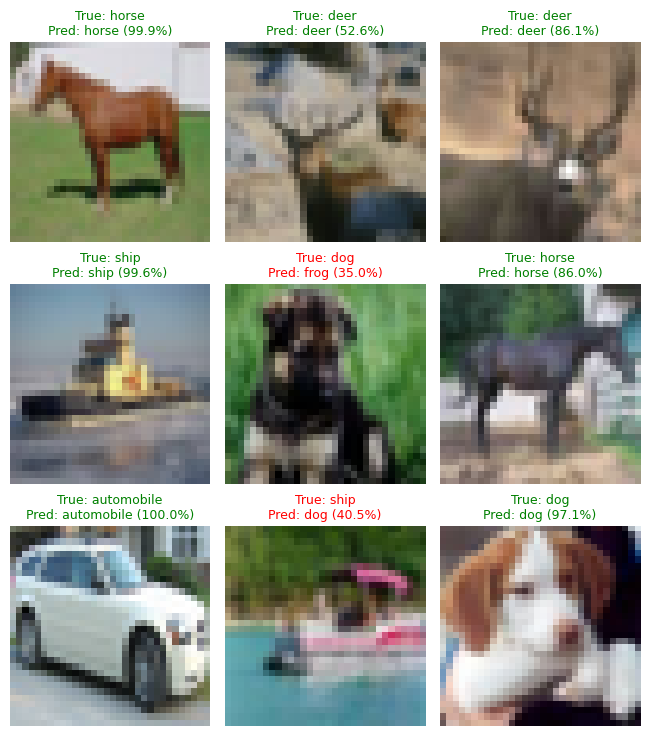

In [31]:
import numpy as np
import matplotlib.pyplot as plt

# CIFAR-10 class names
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

def show_predictions(model, X_test, y_test, num_images=9):
    """
    Randomly picks num_images from X_test, runs predictions,
    and displays them in a grid with predicted vs actual labels.
    """
    # Randomly select indices
    indices = np.random.choice(len(X_test), num_images, replace=False)
    sample_images = X_test[indices]
    sample_labels = y_test[indices].flatten()

    # Get predictions (probabilities -> class index)
    predictions = model.predict(sample_images)
    predicted_classes = np.argmax(predictions, axis=1)
    confidences = np.max(predictions, axis=1)

    # Plot grid
    grid_size = int(np.ceil(np.sqrt(num_images)))
    plt.figure(figsize=(grid_size * 2.2, grid_size * 2.5))

    for i in range(num_images):
        plt.subplot(grid_size, grid_size, i + 1)
        plt.imshow(sample_images[i])
        plt.axis('off')

        true_label = class_names[sample_labels[i]]
        pred_label = class_names[predicted_classes[i]]
        confidence = confidences[i] * 100

        # Green title if correct, red if wrong
        color = 'green' if predicted_classes[i] == sample_labels[i] else 'red'
        plt.title(f"True: {true_label}\nPred: {pred_label} ({confidence:.1f}%)",
                  color=color, fontsize=9)

    plt.tight_layout()
    plt.show()

# Usage:
show_predictions(cnn, X_test, y_test, num_images=9)